# Notebook 1 — Ingeniería del dato

**TFG – Comunidad Valenciana | Fase de Data Engineering**

Este cuaderno documenta la carga, limpieza, transformación y validación del bloque climático de **ERA5-Land** para la Comunidad Valenciana.

En esta fase se trabaja con:
- **ERA5-Land (Copernicus/ECMWF)** como fuente climática principal,
- **cartografía oficial del IGN** para la posterior asignación espacial a nivel municipal,
- dejando para una fase posterior la integración complementaria con **AEMET**, en caso de ser necesaria.

El objetivo es obtener un dataset climático limpio, trazable y reproducible, listo para su integración geoespacial y su uso en fases posteriores de análisis y modelado.


## 0) Librerías, rutas y configuración

Este notebook desarrolla la fase de **ingeniería del dato** del TFG, centrada en la carga, organización, limpieza, transformación y validación inicial de los datos climáticos y geoespaciales empleados en el proyecto.

Con el fin de garantizar la **reproducibilidad** y la **trazabilidad** del pipeline, se estructura el trabajo en distintas capas de almacenamiento:

- `RAW`: datos brutos descargados sin transformar.
- `EXTERNAL`: fuentes auxiliares externas, especialmente cartografía oficial.
- `PROCESSED`: salidas intermedias y datasets ya depurados para fases posteriores.

Se opta por un almacenamiento en ficheros intermedios (`NetCDF`, `CSV`, `GeoJSON`) y por un procesamiento batch apoyado en scripts reproducibles, ya que este enfoque facilita la trazabilidad del pipeline, la inspección manual de resultados y la reutilización del dato procesado en notebooks posteriores del TFG.


En este bloque se importan las librerías necesarias, se definen las rutas del proyecto y se establece una configuración común de trabajo para asegurar consistencia en la ejecución del cuaderno.


Importación de librerías y configuración

In [122]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("seaborn-v0_8")
pd.set_option("display.max_columns", 200)

SEED = 42
np.random.seed(SEED)

In [123]:
print("Versiones principales")
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("geopandas:", gpd.__version__)
print("xarray:", xr.__version__)


Versiones principales
pandas: 3.0.1
numpy: 2.4.3
geopandas: 1.1.3
xarray: 2026.2.0


Rutas del proyecto

In [124]:
# Localizar raíz
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA = ROOT / "DATA"
RAW = DATA / "RAW"
EXT = DATA / "EXTERNAL"
PROC = DATA / "PROCESSED"
OUTS = ROOT / "outputs"

Creación de carpetas

In [125]:
for p in (DATA, RAW, EXT, PROC, OUTS):
    p.mkdir(parents=True, exist_ok=True)

Comprobación de archivos y validación inicial.


In [126]:
ERA5_FILE = RAW / "era5_land_cv_2024_01.nc"
MUNICIPIOS_RAW_FILE = EXT / "municipios" / "recintos_municipales_inspire_peninbal_etrs89.shp"
MUN_CV_FILE = EXT / "municipios_cv.geojson"

print("ROOT:", ROOT)
print("DATA:", DATA)
print("RAW:", RAW)
print("EXT:", EXT)
print("PROC:", PROC)
print("OUTS:", OUTS)

print("\nERA5_FILE:", ERA5_FILE)
print("Existe ERA5:", ERA5_FILE.exists())

print("\nMUNICIPIOS_RAW_FILE:", MUNICIPIOS_RAW_FILE)
print("Existe shapefile municipios:", MUNICIPIOS_RAW_FILE.exists())

print("\nMUN_CV_FILE:", MUN_CV_FILE)
print("Existe geojson CV:", MUN_CV_FILE.exists())

if not ERA5_FILE.exists():
    print("⚠️ ERROR: no existe ERA5")

ROOT: c:\Users\gonza\OneDrive\tfg
DATA: c:\Users\gonza\OneDrive\tfg\DATA
RAW: c:\Users\gonza\OneDrive\tfg\DATA\RAW
EXT: c:\Users\gonza\OneDrive\tfg\DATA\EXTERNAL
PROC: c:\Users\gonza\OneDrive\tfg\DATA\PROCESSED
OUTS: c:\Users\gonza\OneDrive\tfg\outputs

ERA5_FILE: c:\Users\gonza\OneDrive\tfg\DATA\RAW\era5_land_cv_2024_01.nc
Existe ERA5: True

MUNICIPIOS_RAW_FILE: c:\Users\gonza\OneDrive\tfg\DATA\EXTERNAL\municipios\recintos_municipales_inspire_peninbal_etrs89.shp
Existe shapefile municipios: True

MUN_CV_FILE: c:\Users\gonza\OneDrive\tfg\DATA\EXTERNAL\municipios_cv.geojson
Existe geojson CV: True


## 1) Trazabilidad del origen de los datos

En esta fase se documentan las fuentes de datos utilizadas en el notebook, indicando su procedencia, formato, variables principales y función dentro del pipeline. Este criterio responde a los requisitos de trazabilidad y reproducibilidad exigidos en el TFG.

### Fuentes utilizadas en este notebook

- **ERA5-Land (Copernicus / ECMWF)**  
  Reanálisis climático de acceso abierto utilizado como fuente principal del bloque meteorológico.  
  - Formato de trabajo: `NetCDF`
  - Variables empleadas en esta fase: `total_precipitation (tp)`, `2m_temperature (t2m)`, `10m_u_component_of_wind (u10)` y `10m_v_component_of_wind (v10)`
  - Uso en el notebook: carga del dato climático bruto, limpieza, transformación y agregación posterior a escala municipal

- **IGN (Instituto Geográfico Nacional)**  
  Cartografía municipal oficial empleada como base geoespacial del análisis.  
  - Formato de trabajo: `Shapefile` / `GeoJSON`
  - Información empleada: geometrías municipales y códigos territoriales
  - Uso en el notebook: delimitación de la Comunidad Valenciana y asignación espacial de la malla climática a municipios

### Fuente prevista para fases posteriores

- **AEMET OpenData**  
  Fuente complementaria considerada para futuras fases del TFG, especialmente como posible apoyo para contraste y validación externa del bloque climático, pero no utilizada directamente en este notebook.

La selección de estas fuentes responde a criterios de **oficialidad, disponibilidad, trazabilidad y adecuación al problema de estudio**, centrado en la construcción de un dataset climático-geoespacial utilizable en las siguientes fases del TFG.

Este notebook cubre específicamente la construcción de la base climática-geoespacial del TFG a partir de ERA5-Land e IGN. La integración complementaria con fuentes como AEMET, INE, Catastro u otras capas territoriales se abordará en fases posteriores del proyecto, una vez consolidado el dataset municipal base.


## 2) Descarga y preparación inicial de ERA5-Land — *proceso reproducible documentado*

Los datos climáticos utilizados en este TFG proceden de **ERA5-Land** y han sido obtenidos mediante consultas programáticas al servicio de Copernicus a través de `CDSAPI`, con descarga en formato `NetCDF`.

El periodo de estudio considerado en esta fase abarca **enero de 2019 a diciembre de 2024**, organizado en ficheros mensuales. Esta estructura permite mejorar la trazabilidad del proceso, controlar posibles errores por lote y facilitar el reprocesado parcial si fuese necesario.

La ejecución operativa de esta fase no se realiza dentro del notebook, sino mediante scripts externos del proyecto, encargados de:
- la descarga mensual de archivos `NetCDF`,
- la transformación individual de cada fichero a formato tabular,
- y la consolidación posterior en un único dataset climático.

Este diseño permite separar de forma clara:
- la **adquisición del dato**,
- la **transformación técnica por lotes**,
- y la **documentación y validación analítica** dentro del notebook.

Con el fin de facilitar la lectura del cuaderno, a continuación se incluye una plantilla representativa de descarga. Posteriormente, el tratamiento del dato se ilustra sobre un fichero mensual como ejemplo metodológico, antes de trabajar con el dataset consolidado del periodo completo.


Los scripts utilizados en esta fase permiten automatizar el procesamiento completo del periodo de estudio y generar como salida un dataset climático consolidado para fases posteriores del pipeline.


In [127]:
# TEMPLATE (no ejecutar en el notebook)
# import cdsapi
# c = cdsapi.Client()
# c.retrieve(
#   'reanalysis-era5-land',
#   {
#     'variable': [
#        'total_precipitation',
#        '2m_temperature',
#        '10m_u_component_of_wind',
#        '10m_v_component_of_wind'
#     ],
#     'year': ['2024'],
#     'month': ['01'],
#     'day':   [f'{d:02d}' for d in range(1,32)],
#     'time':  [f'{h:02d}:00' for h in range(24)],
#     'data_format': 'netcdf',
#     'download_format': 'unarchived',
#     'area': [40.90, -1.75, 37.70, 0.80]
#   },
#   str(ERA5_FILE)
# )

## 3) Carga de geometrías municipales (IGN) y preparación de la capa base

En esta fase se carga la cartografía municipal oficial del **Instituto Geográfico Nacional (IGN)**, que constituye la base territorial del análisis geoespacial del TFG.

A partir de esta fuente se seleccionan exclusivamente los municipios de la **Comunidad Valenciana**, se armoniza el sistema de referencia espacial a `EPSG:4326` y se genera una capa geográfica depurada y reutilizable para fases posteriores del pipeline.

Esta capa base resulta imprescindible para trasladar la información climática de ERA5-Land, originalmente estructurada en rejilla, a una escala territorial interpretable en términos municipales, lo que permite avanzar hacia el análisis del riesgo climático con una lógica espacial coherente con el objetivo del proyecto.


In [128]:
# Fuente oficial IGN (recintos municipales España)
GDF_MUN_FILE = MUNICIPIOS_RAW_FILE

print("Ruta shapefile:", GDF_MUN_FILE)
print("Existe:", GDF_MUN_FILE.exists())

assert GDF_MUN_FILE.exists(), f"No se encontró el shapefile en {GDF_MUN_FILE}"

# 1) Carga del shapefile bruto
gdf_mun = gpd.read_file(GDF_MUN_FILE)

print("Shape original:", gdf_mun.shape)
print("CRS original:", gdf_mun.crs)
print("Columnas:", gdf_mun.columns.tolist())

# 2) Filtrar Comunidad Valenciana (NUTS2 = ES52)
gdf_cv = gdf_mun[gdf_mun["CODNUT2"] == "ES52"].copy()

# 3) Renombrar y seleccionar columnas útiles
gdf_cv = gdf_cv.rename(columns={"NAMEUNIT": "municipio"})
gdf_cv = gdf_cv[["municipio", "CODNUT2", "CODNUT3", "geometry"]].copy()

# 4) Pasar a WGS84 para joins con ERA5 y visualización
if gdf_cv.crs is None or gdf_cv.crs.to_string() != "EPSG:4326":
    gdf_cv = gdf_cv.to_crs(epsg=4326)

# 5) Guardar capa limpia reutilizable
gdf_cv.to_file(MUN_CV_FILE, driver="GeoJSON")

print("Shape CV:", gdf_cv.shape)
print("CRS final:", gdf_cv.crs)
print("GeoJSON guardado en:", MUN_CV_FILE)

gdf_cv.head(3)

Ruta shapefile: c:\Users\gonza\OneDrive\tfg\DATA\EXTERNAL\municipios\recintos_municipales_inspire_peninbal_etrs89.shp
Existe: True
Shape original: (8132, 10)
CRS original: EPSG:4258
Columnas: ['INSPIREID', 'COUNTRY', 'NATLEV', 'NATLEVNAME', 'NATCODE', 'NAMEUNIT', 'CODNUT1', 'CODNUT2', 'CODNUT3', 'geometry']
Shape CV: (542, 4)
CRS final: EPSG:4326
GeoJSON guardado en: c:\Users\gonza\OneDrive\tfg\DATA\EXTERNAL\municipios_cv.geojson


,municipio,CODNUT2,CODNUT3,geometry
6822,l'Atzúbia,ES52,ES521,"POLYGON ((-0.19632 38.85944, -0.19594 38.86003..."
6823,Agost,ES52,ES521,"POLYGON ((-0.70576 38.45214, -0.68783 38.4595,..."
6824,Agres,ES52,ES521,"POLYGON ((-0.54826 38.80565, -0.54745 38.8056,..."


La preparación de la capa base permite aislar correctamente los `542` municipios de la Comunidad Valenciana a partir de la cartografía oficial del IGN y armonizar su sistema de referencia espacial a `EPSG:4326`. Esta capa geoespacial servirá como base territorial común para las fases posteriores de integración climática y análisis municipal.


### 3.1) Exploración inicial de la cartografía bruta

Antes de utilizar la cartografía en el análisis, se realiza una inspección preliminar del shapefile original para comprobar su estructura, los códigos territoriales disponibles y algunos ejemplos de nombres municipales. Esta revisión permite verificar que la fuente contiene la información necesaria para aislar correctamente la Comunidad Valenciana y preservar una identificación territorial útil para la posterior integración geoespacial del dato climático.


In [129]:
print("Columnas disponibles:")
print(gdf_mun.columns.tolist())

print("\nCódigos NUTS2 disponibles:")
print(sorted(gdf_mun["CODNUT2"].dropna().unique()))

print("\nCódigos NUTS3 de la Comunidad Valenciana:")
print(sorted(gdf_mun.loc[gdf_mun["CODNUT2"] == "ES52", "CODNUT3"].dropna().unique()))

print("\nEjemplo de nombres de municipios:")
display(gdf_mun["NAMEUNIT"].head(20))


Columnas disponibles:
['INSPIREID', 'COUNTRY', 'NATLEV', 'NATLEVNAME', 'NATCODE', 'NAMEUNIT', 'CODNUT1', 'CODNUT2', 'CODNUT3', 'geometry']

Códigos NUTS2 disponibles:
['ES11', 'ES12', 'ES13', 'ES21', 'ES22', 'ES23', 'ES24', 'ES30', 'ES41', 'ES42', 'ES43', 'ES51', 'ES52', 'ES53', 'ES61', 'ES62', 'ES63', 'ES64']

Códigos NUTS3 de la Comunidad Valenciana:
['ES521', 'ES522', 'ES523']

Ejemplo de nombres de municipios:


0                               Sotés
1         Cendea de Olza/Oltza Zendea
2               Valle de Ollo/Ollaran
3                           Orbaizeta
4                              Orbara
5                            Orísoain
6                       Oronz/Orontze
7                             Armiñón
8                 Arratzua-Ubarrundia
9                           Asparrena
10                        Ayala/Aiara
11              Baños de Ebro/Mañueta
12                          Barrundia
13                              Eibar
14                         Ormaiztegi
15                           Oiartzun
16                             Pasaia
17    Soraluze-Placencia de las Armas
18                           Arguedas
19                               Aria
Name: NAMEUNIT, dtype: str

La exploración inicial confirma que la cartografía del IGN incluye los atributos territoriales necesarios para el análisis, entre ellos los códigos NUTS y la denominación municipal. Esto permite identificar de forma fiable los municipios pertenecientes a la Comunidad Valenciana y preparar la capa base para las fases posteriores del pipeline geoespacial.


### 3.2) Validación de la capa geoespacial resultante

Se incorporan validaciones básicas para garantizar la calidad de la capa municipal generada. En concreto, se comprueba la existencia de la columna identificadora del municipio, la coherencia del sistema de referencia espacial final (`EPSG:4326`), el número esperado de municipios de la Comunidad Valenciana y la ausencia de geometrías nulas o inválidas.

Estas comprobaciones permiten asegurar que la capa geoespacial resultante es apta para las fases posteriores de integración climática y análisis territorial.


In [130]:
assert "municipio" in gdf_cv.columns, "Debe existir la columna 'municipio'"
assert gdf_cv.crs is not None and gdf_cv.crs.to_string() == "EPSG:4326", "El CRS final debe ser EPSG:4326"
assert len(gdf_cv) == 542, f"Se esperaban 542 municipios y hay {len(gdf_cv)}"
assert gdf_cv["municipio"].isna().sum() == 0, "Hay municipios sin nombre"
assert gdf_cv.geometry.isna().sum() == 0, "Existen geometrías nulas"
assert gdf_cv.geometry.is_valid.all(), "Existen geometrías inválidas"

print("Validación OK")
print("Municipios validados:", len(gdf_cv))
print("Geometrías nulas:", gdf_cv.geometry.isna().sum())
print("Geometrías válidas:", gdf_cv.geometry.is_valid.all())


Validación OK
Municipios validados: 542
Geometrías nulas: 0
Geometrías válidas: True


La validación confirma que la capa municipal generada contiene los `542` municipios esperados para la Comunidad Valenciana, mantiene un sistema de referencia espacial homogéneo en `EPSG:4326` y no presenta geometrías nulas ni inválidas. Esto permite utilizarla con garantías en las fases posteriores de integración geoespacial del bloque climático.


### 3.3) Función de carga reutilizable de municipios CV

Para evitar repetir el proceso de preparación de la cartografía en ejecuciones posteriores, se define una función de carga directa del GeoJSON ya procesado. Esto mejora la modularidad del notebook, reduce redundancias y facilita la reutilización de la capa geoespacial en las fases posteriores del pipeline.


In [131]:
def load_municipios_cv() -> gpd.GeoDataFrame:
    gdf = gpd.read_file(MUN_CV_FILE)

    if gdf.crs is None or gdf.crs.to_string() != "EPSG:4326":
        gdf = gdf.to_crs(4326)

    assert "municipio" in gdf.columns, "Debe existir la columna 'municipio'"
    assert gdf["municipio"].isna().sum() == 0, "Hay municipios sin nombre"
    assert gdf.geometry.isna().sum() == 0, "Existen geometrías nulas"
    assert gdf.geometry.is_valid.all(), "Existen geometrías inválidas"

    return gdf

gdf_cv = load_municipios_cv()

print("CRS:", gdf_cv.crs)
print("Shape:", gdf_cv.shape)

display(gdf_cv.head())


CRS: EPSG:4326
Shape: (542, 4)


,municipio,CODNUT2,CODNUT3,geometry
0,l'Atzúbia,ES52,ES521,"POLYGON ((-0.19632 38.85944, -0.19594 38.86003..."
1,Agost,ES52,ES521,"POLYGON ((-0.70576 38.45214, -0.68783 38.4595,..."
2,Agres,ES52,ES521,"POLYGON ((-0.54826 38.80565, -0.54745 38.8056,..."
3,Aigües,ES52,ES521,"POLYGON ((-0.39296 38.49175, -0.39256 38.49295..."
4,Albatera,ES52,ES521,"POLYGON ((-0.944 38.25543, -0.94317 38.25509, ..."


La función de carga reutilizable permite recuperar la capa municipal ya depurada con validaciones básicas incorporadas, garantizando consistencia geoespacial y facilitando su reutilización en el resto del pipeline sin repetir el proceso completo de preparación.


### 3.4) Representación cartográfica preliminar de la capa municipal

Con el fin de verificar visualmente la correcta delimitación territorial de la capa geoespacial generada, se realiza una representación cartográfica preliminar de los municipios de la Comunidad Valenciana.

Esta visualización no persigue todavía un análisis espacial avanzado, sino confirmar que la selección territorial, la geometría municipal y el sistema de referencia espacial son coherentes con la fase de integración posterior del dato climático.


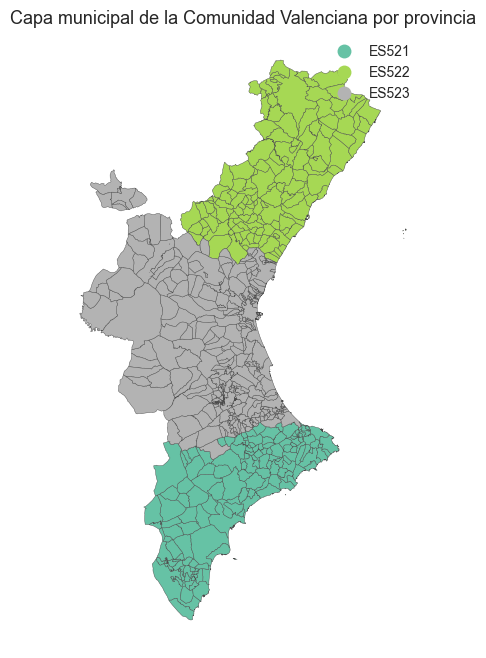

In [132]:
fig, ax = plt.subplots(figsize=(8, 8))

gdf_cv.plot(
    column="CODNUT3",
    ax=ax,
    cmap="Set2",
    edgecolor="#4a4a4a",
    linewidth=0.3,
    legend=True
)

ax.set_title("Capa municipal de la Comunidad Valenciana por provincia", fontsize=13)
ax.set_axis_off()
plt.show()


La representación cartográfica confirma visualmente la correcta delimitación territorial de la capa municipal generada y la coherencia espacial entre las tres provincias de la Comunidad Valenciana. Esta comprobación refuerza la validez de la base geoespacial que se utilizará posteriormente para integrar la información climática a escala municipal.


## 4) Carga de ERA5 (NetCDF) y estructura del dato bruto mensual

Con el fin de facilitar la lectura del notebook, el proceso de carga, inspección y transformación inicial del dato climático se ilustra en este apartado sobre un fichero mensual representativo de **ERA5-Land**.

A partir de este ejemplo se analiza la estructura original del archivo `NetCDF`, sus dimensiones, coordenadas, variables disponibles y posibles registros incompletos derivados de la conversión a formato tabular.

Este análisis permite documentar el funcionamiento del pipeline desde el dato bruto. Posteriormente, el mismo procedimiento se aplica al conjunto completo del periodo **2019-2024** mediante los scripts del proyecto, generando un dataset climático consolidado para las fases posteriores del TFG.


In [133]:
print("Archivo mensual de ejemplo para documentar el pipeline:", ERA5_FILE.name)

assert ERA5_FILE.exists(), f"No se encontró {ERA5_FILE}. Descarga primero el NetCDF."

ds = xr.open_dataset(ERA5_FILE)
print(ds)

Archivo mensual de ejemplo para documentar el pipeline: era5_land_cv_2024_01.nc
<xarray.Dataset> Size: 10MB
Dimensions:     (valid_time: 744, latitude: 33, longitude: 26)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6kB 2024-01-01 ... 2024-01-31T23:...
    expver      (valid_time) <U4 12kB ...
  * latitude    (latitude) float64 264B 40.9 40.8 40.7 40.6 ... 37.9 37.8 37.7
  * longitude   (longitude) float64 208B -1.7 -1.6 -1.5 -1.4 ... 0.5 0.6 0.7 0.8
    number      int64 8B ...
Data variables:
    tp          (valid_time, latitude, longitude) float32 3MB ...
    t2m         (valid_time, latitude, longitude) float32 3MB ...
    u10         (valid_time, latitude, longitude) float32 3MB ...
    v10         (valid_time, latitude, longitude) float32 3MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Eu

In [134]:
print("Dimensiones del dataset:")
print(ds.dims)

print("\nCoordenadas disponibles:")
print(list(ds.coords))

print("\nVariables disponibles:")
print(list(ds.data_vars))

Dimensiones del dataset:
FrozenMappingWarningOnValuesAccess({'valid_time': 744, 'latitude': 33, 'longitude': 26})

Coordenadas disponibles:
['number', 'valid_time', 'latitude', 'longitude', 'expver']

Variables disponibles:
['tp', 't2m', 'u10', 'v10']


In [135]:
df_raw = ds.to_dataframe().reset_index()

print("Shape bruto:", df_raw.shape)
print("\nColumnas originales:")
print(df_raw.columns.tolist())

display(df_raw.head(3))

Shape bruto: (638352, 9)

Columnas originales:
['valid_time', 'latitude', 'longitude', 'tp', 't2m', 'u10', 'v10', 'number', 'expver']


,valid_time,latitude,longitude,tp,t2m,u10,v10,number,expver
0,2024-01-01,40.9,-1.7,0.000144,274.601318,1.743195,0.284660,0,0001
1,2024-01-01,40.9,-1.6,0.000130,274.515381,1.704132,0.202629,0,0001
2,2024-01-01,40.9,-1.5,0.000119,274.441162,1.678741,0.125481,0,0001


La inspección inicial del archivo mensual confirma que ERA5-Land proporciona una estructura regular en rejilla espacio-temporal, con información horaria y variables climáticas clave (`tp`, `t2m`, `u10`, `v10`) adecuadas para el análisis posterior. La conversión a formato tabular permite documentar de forma explícita la estructura del dato bruto antes de aplicar las fases de diagnóstico y limpieza.


### 4.1) Diagnóstico inicial: estructura y valores nulos del dato bruto

Antes de aplicar cualquier proceso de limpieza, se analiza la estructura del dataset bruto generado a partir del archivo NetCDF mensual seleccionado como ejemplo metodológico.

En particular, se revisan las columnas auxiliares del producto ERA5-Land (`expver` y `number`) y la presencia de valores ausentes en las variables climáticas principales (`tp`, `t2m`, `u10`, `v10`).

Este análisis permite distinguir entre problemas reales de calidad del dato y ausencias asociadas a la cobertura espacial de la malla dentro del recorte aplicado. Aunque el diagnóstico se ilustra sobre un fichero mensual representativo, los mismos criterios de revisión y depuración se aplican posteriormente al conjunto completo del periodo 2019-2024.


In [136]:
print("Valores de expver:")
print(df_raw["expver"].value_counts(dropna=False))

print("\nValores de number:")
print(df_raw["number"].value_counts(dropna=False))

print("\nPorcentaje de nulos por columna:")
print((df_raw.isna().mean() * 100).round(2))

print("\nNulos en variables clave (ANTES):")
print(df_raw[["tp", "t2m", "u10", "v10"]].isna().sum())

print("\nNulos en variables estructurales:")
print(df_raw[["valid_time", "latitude", "longitude", "number", "expver"]].isna().sum())

print("\nDescripción estadística bruta de variables climáticas:")
display(df_raw[["tp", "t2m", "u10", "v10"]].describe())


Valores de expver:
expver
0001    638352
Name: count, dtype: int64

Valores de number:
number
0    638352
Name: count, dtype: int64

Porcentaje de nulos por columna:
valid_time     0.00
latitude       0.00
longitude      0.00
tp            35.78
t2m           35.78
u10           35.78
v10           35.78
number         0.00
expver         0.00
dtype: float64

Nulos en variables clave (ANTES):
tp     228408
t2m    228408
u10    228408
v10    228408
dtype: int64

Nulos en variables estructurales:
valid_time    0
latitude      0
longitude     0
number        0
expver        0
dtype: int64

Descripción estadística bruta de variables climáticas:


,tp,t2m,u10,v10
count,409944.000000,409944.000000,409944.000000,409944.000000
mean,0.000517,281.959045,1.489021,-0.407236
std,0.002145,5.119940,2.122336,1.697912
min,0.000000,267.280518,-7.092575,-11.199495
25%,0.000000,278.584717,-0.013935,-1.297302
50%,0.000002,281.837891,1.332115,-0.300292
75%,0.000102,285.224121,2.766026,0.669910
max,0.038310,300.013184,9.973648,9.210770


El diagnóstico inicial muestra que las variables estructurales del archivo (`valid_time`, `latitude`, `longitude`, `number`, `expver`) no presentan ausencias, mientras que los valores nulos se concentran exclusivamente en las variables climáticas. Además, la ausencia de variabilidad en `expver` y `number` indica que el fichero mensual no presenta ambigüedades relevantes de versión o miembro, lo que simplifica su tratamiento posterior.


### 4.1.1) Diagnóstico espacial de valores ausentes

Además del análisis global de valores nulos, se estudia su distribución espacial para comprobar si los registros incompletos se concentran en determinadas zonas de la malla climática.

Este paso permite detectar posibles efectos de borde derivados del recorte geográfico aplicado al dataset y justificar posteriormente el criterio de depuración adoptado. En particular, interesa verificar si los valores ausentes se localizan en áreas periféricas de la rejilla y no en el núcleo territorial de estudio.


Filas con algún nulo: 228408

Coordenadas con nulos (primeras 10):


,latitude,longitude
51,40.8,0.8
101,40.6,0.6
102,40.6,0.7
103,40.6,0.8
127,40.5,0.6
128,40.5,0.7
129,40.5,0.8
152,40.4,0.5
153,40.4,0.6
154,40.4,0.7



Número de coordenadas únicas afectadas:
307


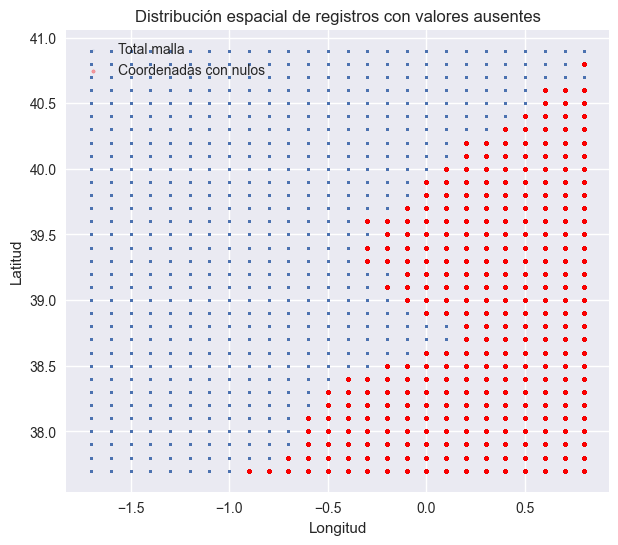

In [137]:
df_nulls = df_raw[df_raw[["tp", "t2m", "u10", "v10"]].isna().any(axis=1)].copy()

print("Filas con algún nulo:", len(df_nulls))

print("\nCoordenadas con nulos (primeras 10):")
display(df_nulls[["latitude", "longitude"]].drop_duplicates().head(10))

print("\nNúmero de coordenadas únicas afectadas:")
print(len(df_nulls[["latitude", "longitude"]].drop_duplicates()))

plt.figure(figsize=(7, 6))

plt.scatter(
    df_raw["longitude"],
    df_raw["latitude"],
    s=3,
    alpha=0.08,
    label="Total malla"
)

plt.scatter(
    df_nulls["longitude"],
    df_nulls["latitude"],
    s=6,
    alpha=0.35,
    color="red",
    label="Coordenadas con nulos"
)

plt.title("Distribución espacial de registros con valores ausentes")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.legend()
plt.show()


El análisis espacial muestra que los valores ausentes no se distribuyen aleatoriamente, sino que se concentran en coordenadas específicas de la rejilla, principalmente asociadas a zonas periféricas del recorte espacial. Este patrón refuerza la interpretación de que los nulos responden a un efecto de borde derivado de la cobertura del archivo y no a un problema generalizado de calidad del dato climático.


### 4.2) Limpieza del dataset climático

Una vez analizada la estructura del dato bruto, se procede a la limpieza del dataset mensual empleado como ejemplo metodológico.

En primer lugar, se renombran las variables espaciales y temporales para homogeneizar la estructura y facilitar su uso en etapas posteriores del análisis. Después, se seleccionan únicamente las variables relevantes del bloque climático y se eliminan las columnas auxiliares utilizadas durante el diagnóstico.

Por último, se descartan los registros que no contienen información completa en las variables climáticas principales (`tp`, `t2m`, `u10`, `v10`). Dado que el análisis previo ha mostrado que estos valores ausentes responden principalmente a efectos de borde de la malla recortada, se opta por excluirlos en esta fase en lugar de imputarlos artificialmente.


In [138]:
df_month = df_raw.rename(columns={
    "valid_time": "time",
    "latitude": "lat",
    "longitude": "lon"
}).copy()

print("Shape inicial:", df_month.shape)

cols_keep = ["time", "lon", "lat", "tp", "t2m", "u10", "v10", "expver"]
df_month = df_month[cols_keep].copy()

# Mantener únicamente la versión principal del producto
df_month = df_month[df_month["expver"] == df_month["expver"].mode()[0]].copy()
df_month = df_month.drop(columns=["expver"], errors="ignore")

print("\nShape antes de eliminar nulos climáticos:", df_month.shape)

df_month = df_month.dropna(subset=["tp", "t2m", "u10", "v10"]).copy()

print("Shape después de limpieza:", df_month.shape)

print("\nNulos en variables clave (DESPUÉS):")
print(df_month[["tp", "t2m", "u10", "v10"]].isna().sum())

n_inicial = len(df_raw)
n_final = len(df_month)
filas_eliminadas = n_inicial - n_final
pct_eliminado = filas_eliminadas / n_inicial * 100

print(f"\nFilas eliminadas: {filas_eliminadas}")
print(f"Porcentaje eliminado: {pct_eliminado:.2f}%")
print("\nLa eliminación afecta a registros con variables climáticas incompletas y mantiene únicamente observaciones utilizables para fases posteriores.")


Shape inicial: (638352, 9)

Shape antes de eliminar nulos climáticos: (638352, 7)
Shape después de limpieza: (409944, 7)

Nulos en variables clave (DESPUÉS):
tp     0
t2m    0
u10    0
v10    0
dtype: int64

Filas eliminadas: 228408
Porcentaje eliminado: 35.78%

La eliminación afecta a registros con variables climáticas incompletas y mantiene únicamente observaciones utilizables para fases posteriores.


La depuración reduce el dataset de 638.352 a 409.944 registros, eliminando un 35,78 % de las filas iniciales. Aunque la proporción es elevada, el análisis previo muestra que estas ausencias se concentran en coordenadas específicas de borde, por lo que no responden a un problema general de calidad del dato, sino a una limitación espacial del recorte aplicado.


In [139]:
assert df_month[["tp", "t2m", "u10", "v10"]].isna().sum().sum() == 0, "Persisten nulos en variables climáticas"
print("Validación de nulos tras limpieza: OK")


Validación de nulos tras limpieza: OK


### 4.3) Transformación de variables y conversión de unidades

Una vez depurado el dataset, se transforman las variables climáticas a unidades más interpretables y utilizables en las fases posteriores del TFG.

En particular:
- `tp` (precipitación total, en metros) se convierte a `precip_mm` (milímetros),
- `t2m` (temperatura a 2 metros, en Kelvin) se transforma en `temp_c` (grados Celsius),
- y las componentes `u10` y `v10` se combinan para obtener `viento_ms`, correspondiente al módulo de la velocidad del viento en metros por segundo.

Estas transformaciones permiten trabajar con magnitudes directamente interpretables desde el punto de vista climático y más adecuadas para su posterior agregación territorial, análisis exploratorio e ingeniería de variables.


In [140]:
df_month["time"] = pd.to_datetime(df_month["time"])
df_month["precip_mm"] = df_month["tp"] * 1000.0
df_month["temp_c"] = df_month["t2m"] - 273.15
df_month["viento_ms"] = np.sqrt(df_month["u10"]**2 + df_month["v10"]**2)

value_cols = ["precip_mm", "temp_c", "viento_ms"]

print("Variables transformadas creadas:", value_cols)
display(df_month[value_cols].describe())

display(df_month.head(3))

print("Precipitación mínima:", df_month["precip_mm"].min())
print("Temperatura mínima:", df_month["temp_c"].min())
print("Temperatura máxima:", df_month["temp_c"].max())
print("Velocidad máxima del viento:", df_month["viento_ms"].max())


Variables transformadas creadas: ['precip_mm', 'temp_c', 'viento_ms']


,precip_mm,temp_c,viento_ms
count,409944.000000,409944.000000,409944.000000
mean,0.516850,8.809073,2.594086
std,2.145141,5.119940,1.743832
min,0.000000,-5.869476,0.006844
25%,0.000000,5.434723,1.386767
50%,0.001729,8.687897,2.087158
75%,0.101978,12.074127,3.364117
max,38.309753,26.863190,13.014453


,time,lon,lat,tp,t2m,u10,v10,precip_mm,temp_c,viento_ms
0,2024-01-01,-1.7,40.9,0.000144,274.601318,1.743195,0.284660,0.144088,1.451324,1.766284
1,2024-01-01,-1.6,40.9,0.000130,274.515381,1.704132,0.202629,0.130051,1.365387,1.716137
2,2024-01-01,-1.5,40.9,0.000119,274.441162,1.678741,0.125481,0.118935,1.291168,1.683425


Precipitación mínima: 0.0
Temperatura mínima: -5.8694763
Temperatura máxima: 26.86319
Velocidad máxima del viento: 13.014453


Los resultados transformados muestran valores coherentes con un contexto invernal en la Comunidad Valenciana: temperaturas moderadas, precipitación muy asimétrica con abundancia de valores próximos a cero y algunos episodios intensos, y velocidades de viento dentro de rangos físicamente plausibles.

### 4.4) Validación final de calidad del dataset climático mensual

Tras la depuración y transformación del archivo mensual utilizado como ejemplo metodológico, se realizan comprobaciones finales para verificar la consistencia estructural del dataset resultante.

En particular, se revisa la ausencia de valores nulos en las variables climáticas transformadas, la coherencia del rango temporal y la estructura final de columnas disponibles. Esta validación permite confirmar que el bloque climático queda preparado para su posterior generalización al conjunto completo del periodo de estudio y para su integración geoespacial en fases posteriores del pipeline.


In [141]:
df_month.sort_values(["time", "lat", "lon"], inplace=True)

print("Nulos finales por columna:")
print(df_month.isna().sum())

print("\nTotal de filas finales:", len(df_month))
print("Rango temporal:", df_month["time"].min(), "→", df_month["time"].max())

print("\nColumnas finales:")
print(df_month.columns.tolist())

assert df_month[["precip_mm", "temp_c", "viento_ms"]].isna().sum().sum() == 0, "Persisten nulos en variables transformadas"
assert df_month.duplicated(subset=["time", "lat", "lon"]).sum() == 0, "Existen duplicados en time-lat-lon"


Nulos finales por columna:
time         0
lon          0
lat          0
tp           0
t2m          0
u10          0
v10          0
precip_mm    0
temp_c       0
viento_ms    0
dtype: int64

Total de filas finales: 409944
Rango temporal: 2024-01-01 00:00:00 → 2024-01-31 23:00:00

Columnas finales:
['time', 'lon', 'lat', 'tp', 't2m', 'u10', 'v10', 'precip_mm', 'temp_c', 'viento_ms']


La validación final confirma que el dataset mensual limpio presenta consistencia estructural, ausencia de valores nulos en las variables transformadas y una granularidad espacio-temporal coherente con el archivo original. De este modo, el ejemplo mensual queda preparado para ilustrar el paso posterior al tratamiento automatizado del periodo completo.


### 4.5) Generalización del pipeline al periodo completo y carga del dataset consolidado

Con el fin de facilitar la lectura del notebook, el proceso de carga, diagnóstico, limpieza y transformación se ha ilustrado previamente sobre un fichero mensual representativo. No obstante, el alcance real de esta fase del TFG corresponde al conjunto completo de datos disponible para el periodo **enero de 2019 - diciembre de 2024**.

Para ello, el mismo pipeline de tratamiento se ejecuta de forma automatizada mediante scripts externos sobre todos los archivos mensuales descargados de ERA5-Land. Como resultado de este proceso, se genera un dataset climático consolidado en formato tabular, que constituye la base real de trabajo para las fases posteriores de integración espacial, agregación municipal y análisis exploratorio.


In [142]:
ERA5_MERGED_FILE = PROC / "dataset_clima_cv_2019_2024_merge.csv"

print("Ruta dataset consolidado:", ERA5_MERGED_FILE)
print("Existe:", ERA5_MERGED_FILE.exists())

assert ERA5_MERGED_FILE.exists(), f"No se encontró {ERA5_MERGED_FILE}"

df_clima = pd.read_csv(ERA5_MERGED_FILE, parse_dates=["time"])

print("Shape:", df_clima.shape)
print("Rango temporal:", df_clima["time"].min(), "→", df_clima["time"].max())
print("Columnas:", df_clima.columns.tolist())

display(df_clima.head(3))

print("Nulos por columna:")
print(df_clima.isna().sum())

print("\nDuplicados time-lat-lon:", df_clima.duplicated(subset=["time", "lat", "lon"]).sum())


Ruta dataset consolidado: c:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_clima_cv_2019_2024_merge.csv
Existe: True
Shape: (28987008, 12)
Rango temporal: 2019-01-01 00:00:00 → 2024-12-31 23:00:00
Columnas: ['time', 'lon', 'lat', 'tp', 't2m', 'u10', 'v10', 'precip_mm', 'temp_c', 'viento_ms', 'year', 'month']


,time,lon,lat,tp,t2m,u10,v10,precip_mm,temp_c,viento_ms,year,month
0,2019-01-01,-1.7,37.7,0.000002,277.06934,1.900787,-0.855180,0.001721,3.919342,2.084305,2019,1
1,2019-01-01,-1.6,37.7,0.000002,277.39355,1.940826,-0.841996,0.001721,4.243561,2.115600,2019,1
2,2019-01-01,-1.5,37.7,0.000002,277.27440,2.016998,-0.811723,0.001721,4.124420,2.174207,2019,1


Nulos por columna:
time         0
lon          0
lat          0
tp           0
t2m          0
u10          0
v10          0
precip_mm    0
temp_c       0
viento_ms    0
year         0
month        0
dtype: int64

Duplicados time-lat-lon: 0


La carga del dataset consolidado confirma que el pipeline automatizado aplicado sobre el periodo 2019-2024 reproduce de forma consistente los criterios de limpieza y transformación ilustrados previamente sobre el fichero mensual de ejemplo. El resultado es una base climática completa, sin valores nulos ni duplicados espacio-temporales, preparada para su posterior integración geoespacial a escala municipal.


## 5) Asignación espacial ERA5 → Municipios

A partir de este punto, la integración espacial se realiza sobre el **dataset climático consolidado del periodo 2019-2024**, generado mediante los scripts del proyecto y cargado en el apartado anterior.

Dado el volumen del dataset climático y la resolución espacial de ERA5-Land, la asignación territorial no se realiza observación por observación, sino a partir de la **rejilla espacial única** del modelo. Para ello, se identifican primero las coordenadas `lon-lat` únicas del dataset climático y posteriormente se asigna a cada municipio una celda ERA5 representativa mediante proximidad espacial.

Este enfoque permite mantener la coherencia territorial del análisis, mejorar la cobertura municipal y evitar un coste computacional excesivo en la fase de integración geoespacial. Como resultado, la asignación se resuelve sobre una estructura espacial reducida y después se propaga al conjunto completo de observaciones climáticas mediante uniones tabulares.


### 5.1) Extracción de la rejilla espacial única de ERA5

Aunque el dataset climático consolidado contiene millones de observaciones temporales, todas ellas se apoyan sobre una rejilla espacial limitada de coordenadas `lon-lat` que se repiten a lo largo del tiempo.

Por ello, antes de realizar la asignación municipal, se extraen las celdas espaciales únicas de ERA5-Land. Esta reducción permite resolver la correspondencia geoespacial sobre una estructura compacta, eficiente y reutilizable para el resto del pipeline.


In [143]:
grid_era5 = df_clima[["lon", "lat"]].drop_duplicates().reset_index(drop=True).copy()

print("Número de celdas ERA5 únicas:", len(grid_era5))

gdf_grid = gpd.GeoDataFrame(
    grid_era5,
    geometry=gpd.points_from_xy(grid_era5["lon"], grid_era5["lat"]),
    crs="EPSG:4326"
)

display(gdf_grid.head())


Número de celdas ERA5 únicas: 551


,lon,lat,geometry
0,-1.7,37.7,POINT (-1.7 37.7)
1,-1.6,37.7,POINT (-1.6 37.7)
2,-1.5,37.7,POINT (-1.5 37.7)
3,-1.4,37.7,POINT (-1.4 37.7)
4,-1.3,37.7,POINT (-1.3 37.7)


La extracción de la rejilla confirma que el dataset climático completo se apoya sobre un número reducido de celdas espaciales (`551`), muy inferior al volumen total de observaciones temporales. Esta reducción justifica el uso de una estrategia de asignación espacial basada en la rejilla única, evitando operaciones geoespaciales repetitivas sobre millones de registros.


### 5.2) Construcción de una referencia espacial municipal

Para asignar una celda climática a cada municipio, se construye un punto representativo de cada polígono municipal. En lugar de utilizar directamente el centroide geométrico, se emplea `representative_point()`, ya que garantiza que el punto de referencia queda situado dentro del polígono.

Este punto representativo actúa como referencia territorial para buscar posteriormente la celda ERA5 más próxima, evitando problemas potenciales en municipios con geometrías irregulares o alargadas.


In [144]:
gdf_municipios_ref = gdf_cv.copy()
gdf_municipios_ref["geometry_rep"] = gdf_municipios_ref.representative_point()

gdf_municipios_ref = gpd.GeoDataFrame(
    gdf_municipios_ref.drop(columns="geometry"),
    geometry=gdf_municipios_ref["geometry_rep"],
    crs="EPSG:4326"
).drop(columns="geometry_rep", errors="ignore")

print("Municipios de referencia:", len(gdf_municipios_ref))
display(gdf_municipios_ref.head())


Municipios de referencia: 542


,municipio,CODNUT2,CODNUT3,geometry
0,l'Atzúbia,ES52,ES521,POINT (-0.17541 38.86048)
1,Agost,ES52,ES521,POINT (-0.64994 38.44927)
2,Agres,ES52,ES521,POINT (-0.50884 38.78263)
3,Aigües,ES52,ES521,POINT (-0.36373 38.50901)
4,Albatera,ES52,ES521,POINT (-0.89041 38.21538)


La capa de referencia municipal conserva los `542` municipios de la Comunidad Valenciana y sustituye temporalmente la geometría poligonal por un punto interno representativo. Esta estructura simplifica la fase de asignación espacial posterior sin perder la correspondencia territorial a nivel municipal.


### 5.3) Asignación municipio → celda ERA5 más cercana

Una vez obtenidas la rejilla única de ERA5 y la referencia espacial interna de cada municipio, se asigna a cada municipio la celda climática más cercana.

Este criterio permite obtener cobertura territorial completa incluso en municipios pequeños o costeros que no contienen directamente un punto de la rejilla en su interior. Aunque este enfoque simplifica la representación espacial, resulta adecuado para una rejilla climática de resolución moderada como ERA5-Land y mejora notablemente la utilidad del dataset a escala municipal.



In [145]:
gdf_municipios_ref_proj = gdf_municipios_ref.to_crs(epsg=25830)
gdf_grid_proj = gdf_grid.to_crs(epsg=25830)

gdf_assign = gpd.sjoin_nearest(
    gdf_municipios_ref_proj,
    gdf_grid_proj[["lon", "lat", "geometry"]],
    how="left",
    distance_col="dist_metros"
).to_crs(epsg=4326)

print("Municipios asignados:", len(gdf_assign))
print("Municipios sin celda asignada:", gdf_assign["lon"].isna().sum())
print("Distancia media (m):", round(gdf_assign["dist_metros"].mean(), 2))
print("Distancia máxima (m):", round(gdf_assign["dist_metros"].max(), 2))

display(gdf_assign[["municipio", "CODNUT2", "CODNUT3", "lon", "lat", "dist_metros"]].head())

assert len(gdf_assign) == 542, "No se han asignado todos los municipios"
assert gdf_assign["lon"].isna().sum() == 0, "Existen municipios sin celda ERA5 asignada"



Municipios asignados: 542
Municipios sin celda asignada: 0
Distancia media (m): 3879.91
Distancia máxima (m): 8970.33


,municipio,CODNUT2,CODNUT3,lon,lat,dist_metros
0,l'Atzúbia,ES52,ES521,-0.2,38.9,4879.857411
1,Agost,ES52,ES521,-0.6,38.4,6996.059580
2,Agres,ES52,ES521,-0.5,38.8,2075.930152
3,Aigües,ES52,ES521,-0.4,38.5,3318.679776
4,Albatera,ES52,ES521,-0.9,38.2,1902.153903


La asignación por proximidad permite asociar una celda ERA5 a la totalidad de los `542` municipios de la Comunidad Valenciana, superando la limitada cobertura obtenida con el criterio inicial `within`, que solo permitía asignar observaciones a `183` municipios.


La distancia media entre el punto representativo municipal y la celda asignada se sitúa en torno a `3,9 km`, con una distancia máxima inferior a `9 km`, valores coherentes con la resolución espacial aproximada de ERA5-Land. Estos resultados apoyan la idoneidad del criterio adoptado para construir un dataset climático municipal completo y operativamente utilizable.


### 5.3.1) Diagnóstico de calidad de la asignación espacial
El diagnóstico de asignación espacial permite evaluar hasta qué punto la aproximación por proximidad representa adecuadamente la escala municipal. La distribución de distancias entre municipios y celdas ERA5, junto con el número de municipios que comparten una misma celda climática, ofrece una medida útil del grado de simplificación espacial introducido por el método.


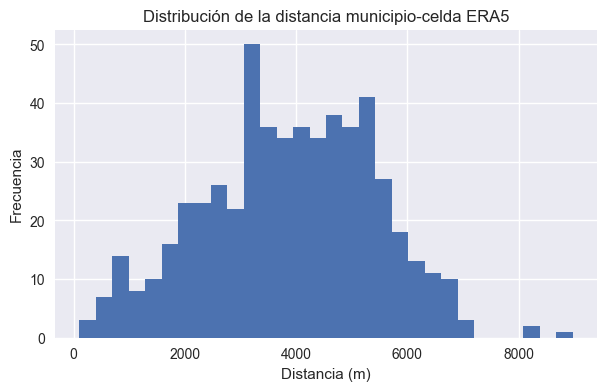

Resumen de municipios por celda ERA5:


count    205.000000
mean       2.643902
std        2.310467
min        1.000000
25%        1.000000
50%        2.000000
75%        3.000000
max       15.000000
Name: num_municipios, dtype: float64


Máximo de municipios compartiendo la misma celda:
15


In [154]:
plt.figure(figsize=(7, 4))
gdf_assign["dist_metros"].hist(bins=30)
plt.title("Distribución de la distancia municipio-celda ERA5")
plt.xlabel("Distancia (m)")
plt.ylabel("Frecuencia")
plt.show()

cell_usage = (
    gdf_assign.groupby(["lon", "lat"])
    .size()
    .reset_index(name="num_municipios")
    .sort_values("num_municipios", ascending=False)
)

print("Resumen de municipios por celda ERA5:")
display(cell_usage["num_municipios"].describe())

print("\nMáximo de municipios compartiendo la misma celda:")
print(cell_usage["num_municipios"].max())


El diagnóstico confirma que la asignación por proximidad introduce una simplificación espacial asumible dentro del contexto del proyecto. La mayoría de los municipios quedan asociados a celdas ERA5 relativamente próximas, con una distancia media inferior a `4 km` y una distancia máxima inferior a `9 km`, valores coherentes con la resolución espacial del reanálisis.

Asimismo, aunque varios municipios pueden compartir una misma celda climática, el reparto observado muestra que esta situación responde a la propia escala de la rejilla y no impide construir una base municipal completa y operativamente utilizable para el resto del pipeline.


### 5.4) Integración del clima consolidado con la asignación municipal

Una vez establecida la correspondencia entre municipios y celdas ERA5, se integra dicha asignación con el dataset climático consolidado mediante una unión tabular por coordenadas `lon-lat`.

De este modo, cada observación climática hereda el municipio al que ha sido asociada su celda de referencia, permitiendo construir posteriormente series temporales municipales sin necesidad de repetir operaciones geoespaciales sobre millones de registros.



In [146]:
muni_lookup = gdf_assign[["municipio", "CODNUT2", "CODNUT3", "lon", "lat", "dist_metros"]].copy()

df_clima_municipios = df_clima.merge(
    muni_lookup,
    on=["lon", "lat"],
    how="inner"
)

print("Shape clima + municipio:", df_clima_municipios.shape)
print("Municipios únicos:", df_clima_municipios["municipio"].nunique())
print("Rango temporal:",
      df_clima_municipios["time"].min(),
      "→",
      df_clima_municipios["time"].max())

display(df_clima_municipios.head(5))
assert df_clima_municipios["municipio"].isna().sum() == 0, "Existen observaciones sin municipio"
assert df_clima_municipios["municipio"].nunique() == 542, "No están representados todos los municipios"


Shape clima + municipio: (28513536, 16)
Municipios únicos: 542
Rango temporal: 2019-01-01 00:00:00 → 2024-12-31 23:00:00


,time,lon,lat,tp,t2m,u10,v10,precip_mm,temp_c,viento_ms,year,month,municipio,CODNUT2,CODNUT3,dist_metros
0,2019-01-01,-0.8,37.9,0.000002,281.28027,2.141998,-0.604692,0.001721,8.130280,2.225715,2019,1,Pilar de la Horadada,ES52,ES521,2266.994476
1,2019-01-01,-0.9,38.0,0.000002,278.22950,1.726959,-1.070512,0.001721,5.079498,2.031843,2019,1,Orihuela,ES52,ES521,3142.589008
2,2019-01-01,-0.8,38.0,0.000002,278.81738,1.930084,-0.888383,0.001721,5.667389,2.124723,2019,1,Jacarilla,ES52,ES521,6645.996510
3,2019-01-01,-0.8,38.0,0.000002,278.81738,1.930084,-0.888383,0.001721,5.667389,2.124723,2019,1,San Miguel de Salinas,ES52,ES521,2621.265112
4,2019-01-01,-0.7,38.0,0.000002,279.74902,2.087311,-0.744340,0.001721,6.599030,2.216057,2019,1,Torrevieja,ES52,ES521,872.058331


La integración tabular entre el dataset climático consolidado y la tabla de asignación municipal permite construir un bloque climático territorializado para el conjunto completo del periodo 2019-2024. El resultado mantiene la cobertura temporal total del estudio y garantiza representación para los `542` municipios de la Comunidad Valenciana.


### 5.5) Construcción del dataset municipal horario

Una vez integrada la correspondencia entre municipios y celdas ERA5 en el dataset climático consolidado, se obtiene directamente una serie climática con granularidad municipal y horaria.

Dado que cada municipio queda asociado a una única celda ERA5 representativa, la integración tabular ya produce una estructura a nivel `municipio-time`, sin necesidad de una reducción adicional de observaciones. No obstante, este paso permite verificar formalmente dicha granularidad y consolidar una base intermedia homogénea para la posterior construcción del dataset diario.


In [147]:
print("Filas antes:", len(df_clima_municipios))

df_municipios_time = (
    df_clima_municipios
    .groupby(["municipio", "CODNUT2", "CODNUT3", "time"], as_index=False)
    .agg({
        "precip_mm": "mean",
        "temp_c": "mean",
        "viento_ms": "mean",
        "lon": "mean",
        "lat": "mean",
        "dist_metros": "mean"
    })
)

print("Filas después:", len(df_municipios_time))
print("Duplicados municipio-time antes de agrupar:",
      df_clima_municipios.duplicated(subset=["municipio", "time"]).sum())

print("\nMunicipios:", df_municipios_time["municipio"].nunique())
print("Rango temporal:",
      df_municipios_time["time"].min(),
      "→",
      df_municipios_time["time"].max())

display(df_municipios_time.head())


Filas antes: 28513536
Filas después: 28513536
Duplicados municipio-time antes de agrupar: 0

Municipios: 542
Rango temporal: 2019-01-01 00:00:00 → 2024-12-31 23:00:00


,municipio,CODNUT2,CODNUT3,time,precip_mm,temp_c,viento_ms,lon,lat,dist_metros
0,Ademuz,ES52,ES523,2019-01-01 00:00:00,0.001721,-2.377533,1.789321,-1.2,40.1,5806.682345
1,Ademuz,ES52,ES523,2019-01-01 01:00:00,0.000000,-2.503265,1.825996,-1.2,40.1,5806.682345
2,Ademuz,ES52,ES523,2019-01-01 02:00:00,0.000000,-2.513763,1.830882,-1.2,40.1,5806.682345
3,Ademuz,ES52,ES523,2019-01-01 03:00:00,0.000000,-2.520355,1.835109,-1.2,40.1,5806.682345
4,Ademuz,ES52,ES523,2019-01-01 04:00:00,0.000000,-2.527191,1.817236,-1.2,40.1,5806.682345


La igualdad entre el número de filas antes y después del agrupamiento confirma que, bajo el criterio de asignación adoptado, el dataset ya presentaba una única observación por municipio y hora. Por tanto, este bloque actúa principalmente como validación estructural del nivel municipal-horario previo a la agregación diaria.


### 5.6) Construcción del dataset municipal diario

A partir de la serie climática municipal horaria, se construye una versión agregada diaria por municipio. Esta transformación reduce la dimensionalidad temporal del problema y facilita la creación de indicadores climáticos relevantes para el análisis posterior del riesgo.

Se calculan agregados coherentes con la naturaleza de cada variable: precipitación acumulada diaria, temperatura media/máxima/mínima, viento medio/máximo y amplitud térmica diaria.


In [148]:
df_municipios_time["time"] = pd.to_datetime(df_municipios_time["time"])
df_municipios_time["fecha"] = df_municipios_time["time"].dt.floor("D")

df_municipios_dia = (
    df_municipios_time
    .groupby(["municipio", "CODNUT2", "CODNUT3", "fecha"], as_index=False)
    .agg(
        precip_total_dia=("precip_mm", "sum"),
        temp_media_dia=("temp_c", "mean"),
        temp_max_dia=("temp_c", "max"),
        temp_min_dia=("temp_c", "min"),
        viento_medio_dia=("viento_ms", "mean"),
        viento_max_dia=("viento_ms", "max"),
        lon=("lon", "mean"),
        lat=("lat", "mean"),
        dist_metros=("dist_metros", "mean")
    )
    .sort_values(["municipio", "fecha"])
    .reset_index(drop=True)
)

df_municipios_dia["amplitud_termica_dia"] = (
    df_municipios_dia["temp_max_dia"] - df_municipios_dia["temp_min_dia"]
)

print("Shape dataset diario:", df_municipios_dia.shape)
display(df_municipios_dia.head())
print("Municipios:", df_municipios_dia["municipio"].nunique())
print("Fechas:", df_municipios_dia["fecha"].nunique())
print("Rango temporal:", df_municipios_dia["fecha"].min(), "→", df_municipios_dia["fecha"].max())


Shape dataset diario: (1188064, 14)


,municipio,CODNUT2,CODNUT3,fecha,precip_total_dia,temp_media_dia,temp_max_dia,temp_min_dia,viento_medio_dia,viento_max_dia,lon,lat,dist_metros,amplitud_termica_dia
0,Ademuz,ES52,ES523,2019-01-01,0.001721,2.735280,12.305084,-2.840179,1.430405,1.927332,-1.2,40.1,5806.682345,15.145263
1,Ademuz,ES52,ES523,2019-01-02,0.014512,1.408661,8.768463,-2.744965,2.487614,3.134458,-1.2,40.1,5806.682345,11.513428
2,Ademuz,ES52,ES523,2019-01-03,0.000852,1.463847,7.518707,-3.328705,1.271294,1.983465,-1.2,40.1,5806.682345,10.847412
3,Ademuz,ES52,ES523,2019-01-04,0.014490,1.935232,10.640778,-4.029633,1.283369,1.690730,-1.2,40.1,5806.682345,14.670411
4,Ademuz,ES52,ES523,2019-01-05,0.000852,1.852412,10.552155,-4.144867,2.385710,3.107875,-1.2,40.1,5806.682345,14.697022


Municipios: 542
Fechas: 2192
Rango temporal: 2019-01-01 00:00:00 → 2024-12-31 00:00:00


La agregación diaria genera un dataset municipal con `1.188.064` observaciones, correspondiente a los `542` municipios de la Comunidad Valenciana a lo largo de `2.192` días del periodo 2019-2024. Esta estructura constituye la base operativa para la fase posterior de ingeniería de variables, análisis exploratorio y modelado del riesgo climático.


### 5.7) Validación del dataset municipal diario

Se realizan comprobaciones finales para validar la consistencia del dataset municipal diario generado a partir del periodo completo 2019-2024.

En particular, se revisan la cobertura municipal, la cobertura temporal, la ausencia de valores nulos, la existencia de duplicados y la distancia de asignación entre cada municipio y su celda ERA5 asociada, con el fin de evaluar la calidad estructural y territorial de la aproximación adoptada.


In [149]:
print("Municipios:", df_municipios_dia["municipio"].nunique())
print("Fechas:", df_municipios_dia["fecha"].nunique())

print("\nNulos:")
print(df_municipios_dia.isna().sum())

print("\nDuplicados (municipio-fecha):",
      df_municipios_dia.duplicated(subset=["municipio", "fecha"]).sum())

dias_por_municipio = df_municipios_dia.groupby("municipio")["fecha"].nunique()

print("\nResumen días por municipio:")
print(dias_por_municipio.describe())

print("\nMunicipios con cobertura incompleta:",
      (dias_por_municipio < dias_por_municipio.max()).sum())

print("\nDistancia media municipio-celda (m):",
      round(df_municipios_dia["dist_metros"].mean(), 2))
print("Distancia máxima municipio-celda (m):",
      round(df_municipios_dia["dist_metros"].max(), 2))

assert df_municipios_dia["municipio"].nunique() == 542, "No están representados todos los municipios"
assert df_municipios_dia["fecha"].nunique() == 2192, "El número de días no coincide con el periodo esperado"
assert df_municipios_dia.isna().sum().sum() == 0, "Existen valores nulos en el dataset diario"
assert df_municipios_dia.duplicated(subset=["municipio", "fecha"]).sum() == 0, "Existen duplicados municipio-fecha"


Municipios: 542
Fechas: 2192

Nulos:
municipio               0
CODNUT2                 0
CODNUT3                 0
fecha                   0
precip_total_dia        0
temp_media_dia          0
temp_max_dia            0
temp_min_dia            0
viento_medio_dia        0
viento_max_dia          0
lon                     0
lat                     0
dist_metros             0
amplitud_termica_dia    0
dtype: int64

Duplicados (municipio-fecha): 0

Resumen días por municipio:
count     542.0
mean     2192.0
std         0.0
min      2192.0
25%      2192.0
50%      2192.0
75%      2192.0
max      2192.0
Name: fecha, dtype: float64

Municipios con cobertura incompleta: 0

Distancia media municipio-celda (m): 3879.91
Distancia máxima municipio-celda (m): 8970.33


La validación final confirma que el dataset diario resultante cubre la totalidad de los `542` municipios de la Comunidad Valenciana y mantiene una serie temporal completa de `2.192` días para cada uno de ellos. No se detectan valores nulos ni duplicados en la combinación `municipio-fecha`, y las distancias de asignación obtenidas resultan coherentes con la resolución espacial de ERA5-Land.

En conjunto, estas comprobaciones respaldan la consistencia estructural y territorial del dataset generado para las fases posteriores del TFG.


La metodología adoptada permite construir un dataset climático municipal diario completo para la Comunidad Valenciana, manteniendo cobertura territorial total y consistencia temporal en todo el periodo 2019-2024. Esta base constituye el punto de partida para las fases posteriores de ingeniería de variables, análisis exploratorio y modelado del riesgo climático.

Como limitación metodológica, debe tenerse en cuenta que la asignación por proximidad puede hacer que varios municipios compartan una misma celda ERA5, especialmente en zonas donde la resolución espacial del reanálisis es más gruesa que la escala administrativa municipal. No obstante, esta simplificación resulta asumible en el contexto del proyecto y permite obtener una cobertura territorial completa y operativamente utilizable.


### 5.8) Exportación del dataset final

Una vez validada la consistencia estructural y territorial del dataset municipal diario, se procede a su exportación en formato tabular para su uso en las fases posteriores del TFG.

Este fichero constituye la salida principal del bloque de ingeniería del dato y servirá como base para la ingeniería de variables, el análisis exploratorio y el modelado del riesgo climático.


In [150]:
OUT_FILE = PROC / "dataset_cv_municipios.csv"
OUT_FILE.parent.mkdir(parents=True, exist_ok=True)

df_municipios_dia.to_csv(OUT_FILE, index=False)

print("Dataset guardado en:", OUT_FILE)
print("Shape:", df_municipios_dia.shape)


Dataset guardado en: c:\Users\gonza\OneDrive\tfg\DATA\PROCESSED\dataset_cv_municipios.csv
Shape: (1188064, 14)


El fichero exportado `dataset_cv_municipios.csv` constituye la salida principal del bloque de ingeniería del dato. En él se recoge la información climática diaria agregada a nivel municipal para los `542` municipios de la Comunidad Valenciana durante el periodo 2019-2024, quedando preparado para su uso en las fases posteriores de ingeniería de variables, análisis exploratorio y modelado del riesgo climático.


## Diccionario de datos del dataset final

A continuación se resume la estructura del dataset municipal diario generado en este notebook, indicando el significado de cada variable, su unidad y su granularidad analítica.

| Columna | Significado | Unidad | Granularidad |
|---|---|---|---|
| `municipio` | Nombre del municipio de la Comunidad Valenciana | - | Municipio-día |
| `CODNUT2` | Código NUTS2 de la comunidad autónoma | - | Municipio-día |
| `CODNUT3` | Código NUTS3 de la provincia | - | Municipio-día |
| `fecha` | Fecha de la observación agregada | Fecha | Municipio-día |
| `precip_total_dia` | Precipitación total diaria agregada | mm | Municipio-día |
| `temp_media_dia` | Temperatura media diaria | °C | Municipio-día |
| `temp_max_dia` | Temperatura máxima diaria | °C | Municipio-día |
| `temp_min_dia` | Temperatura mínima diaria | °C | Municipio-día |
| `viento_medio_dia` | Velocidad media diaria del viento | m/s | Municipio-día |
| `viento_max_dia` | Velocidad máxima diaria del viento | m/s | Municipio-día |
| `lon` | Longitud representativa de la celda ERA5 asignada | grados decimales | Municipio-día |
| `lat` | Latitud representativa de la celda ERA5 asignada | grados decimales | Municipio-día |
| `dist_metros` | Distancia entre el municipio y la celda ERA5 asignada | metros | Municipio-día |
| `amplitud_termica_dia` | Diferencia entre temperatura máxima y mínima diaria | °C | Municipio-día |


Este diccionario resume las variables disponibles en la salida final del bloque de ingeniería del dato y facilita su interpretación y reutilización en las fases posteriores del TFG.


## 6) EDA preliminar (para la rúbrica)

Se realiza un análisis exploratorio básico del dataset municipal diario con el objetivo de validar su coherencia y detectar patrones generales en las variables climáticas.

Este análisis incluye:
- distribución de variables,
- relaciones entre variables,
- representación espacial preliminar,
- y una consideración metodológica sobre valores extremos.

El objetivo no es extraer conclusiones definitivas, sino verificar la calidad del dataset antes de la fase de ingeniería de variables.


### 6.1) Distribución de la precipitación diaria


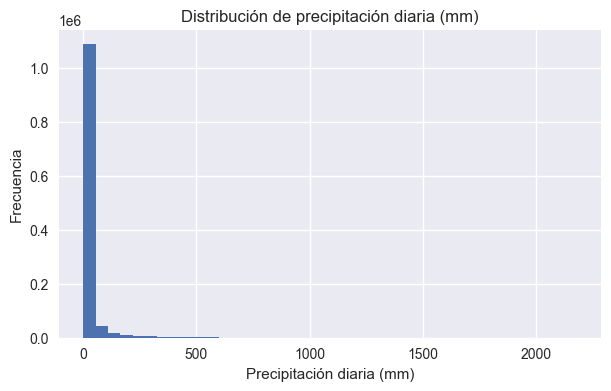

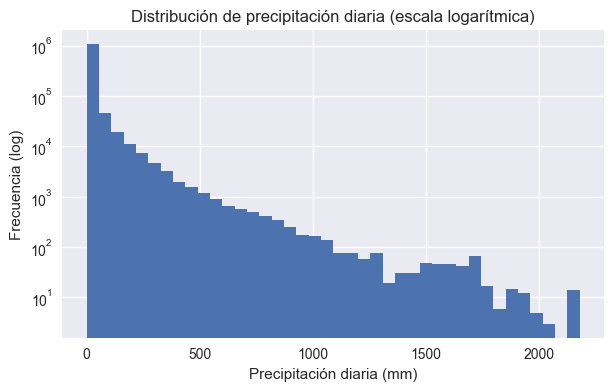

In [151]:
plt.figure(figsize=(7, 4))
df_municipios_dia["precip_total_dia"].hist(bins=40)
plt.title("Distribución de precipitación diaria (mm)")
plt.xlabel("Precipitación diaria (mm)")
plt.ylabel("Frecuencia")
plt.show()

plt.figure(figsize=(7, 4))
df_municipios_dia["precip_total_dia"].hist(bins=40, log=True)
plt.title("Distribución de precipitación diaria (escala logarítmica)")
plt.xlabel("Precipitación diaria (mm)")
plt.ylabel("Frecuencia (log)")
plt.show()


El histograma en escala lineal permite observar la forma general de la distribución de la precipitación diaria en el conjunto del dataset. Se aprecia una fuerte concentración de observaciones en valores muy bajos o próximos a cero, lo que indica que la mayor parte de los días y municipios presentan precipitaciones reducidas. Esta estructura es coherente con la naturaleza intermitente de la precipitación.


La representación en escala logarítmica permite visualizar con mayor claridad la cola de la distribución, haciendo visibles observaciones poco frecuentes que en escala lineal quedan prácticamente ocultas por la acumulación de valores bajos. Este gráfico resulta útil para identificar la presencia de episodios intensos de precipitación y confirmar que el dataset contiene eventos extremos potencialmente relevantes para el análisis del riesgo climático.


### 6.2) Relación entre variables climáticas agregadas


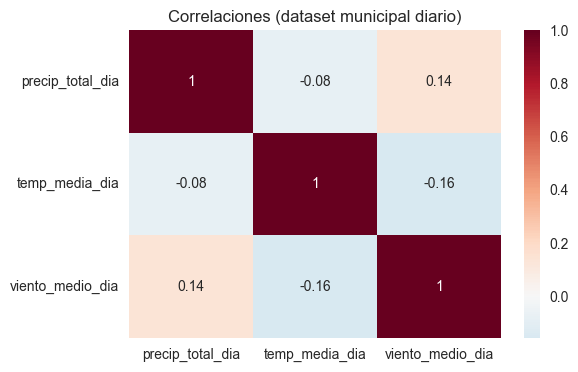

In [152]:
num_cols = ["precip_total_dia", "temp_media_dia", "viento_medio_dia"]

plt.figure(figsize=(6, 4))
sns.heatmap(df_municipios_dia[num_cols].corr(), annot=True, cmap="RdBu_r", center=0)
plt.title("Correlaciones (dataset municipal diario)")
plt.show()


El mapa de correlaciones permite evaluar la intensidad y el signo de la relación lineal entre las principales variables climáticas agregadas. En este caso, las correlaciones observadas son en general  bajas o moderadas, lo que sugiere que precipitación, temperatura y viento recogen dimensiones meteorológicas parcialmente diferenciadas. Este resultado refuerza el interés de conservarlas como variables independientes en fases posteriores del análisis.


### 6.3) Representación espacial preliminar


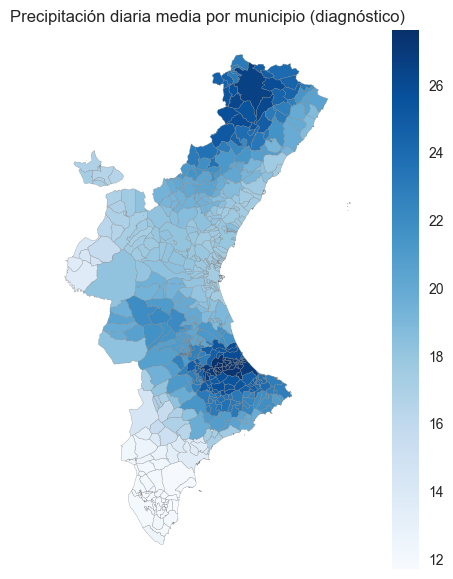

In [153]:
gmap = gdf_cv.merge(
    df_municipios_dia.groupby("municipio")["precip_total_dia"].mean().reset_index(),
    on="municipio",
    how="left"
)

ax = gmap.plot(
    column="precip_total_dia",
    cmap="Blues",
    legend=True,
    figsize=(7, 7),
    edgecolor="grey",
    linewidth=0.2
)

plt.title("Precipitación diaria media por municipio (diagnóstico)")
plt.axis("off")
plt.show()


La representación espacial de la precipitación diaria media permite identificar diferencias territoriales entre municipios de la Comunidad Valenciana. Aunque se trata de una visualización preliminar, el mapa sugiere la existencia de heterogeneidad espacial en el comportamiento climático, lo que resulta coherente con el objetivo del TFG de analizar el riesgo desde una perspectiva geoespacial y municipal.


### 6.4) Consideración metodológica sobre valores extremos

En el contexto climático, la presencia de valores extremos no debe interpretarse automáticamente como un error del dato. Variables como la precipitación o el viento pueden presentar episodios intensos poco frecuentes que, lejos de constituir anomalías espurias, resultan especialmente relevantes para el análisis del riesgo.

Por ello, en esta fase no se aplica una eliminación automática de outliers. En su lugar, se realiza una inspección descriptiva básica para comprobar que los valores extremos observados se mantienen dentro de rangos físicamente plausibles y son coherentes con la naturaleza del fenómeno estudiado.


In [155]:
extremos = df_municipios_dia[[
    "precip_total_dia",
    "temp_media_dia",
    "temp_max_dia",
    "temp_min_dia",
    "viento_medio_dia",
    "viento_max_dia",
    "amplitud_termica_dia"
]].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T

display(extremos)

print("Máxima precipitación diaria:", df_municipios_dia["precip_total_dia"].max())
print("Máxima temperatura media diaria:", df_municipios_dia["temp_media_dia"].max())
print("Mínima temperatura media diaria:", df_municipios_dia["temp_media_dia"].min())
print("Máxima velocidad media diaria del viento:", df_municipios_dia["viento_medio_dia"].max())
print("Máxima velocidad máxima diaria del viento:", df_municipios_dia["viento_max_dia"].max())


,count,mean,std,min,1%,5%,95%,99%,max
precip_total_dia,1188064.0,20.141272,74.803384,0.000000,0.000000,0.000870,99.960950,339.576284,2179.268299
temp_media_dia,1188064.0,16.741377,6.540275,-5.844452,3.497837,6.714600,27.284363,29.281209,33.736379
temp_max_dia,1188064.0,21.677224,6.959370,-2.026459,7.494691,11.094635,33.130035,36.307526,44.204500
temp_min_dia,1188064.0,12.256865,6.284370,-13.256683,-1.048920,2.234320,22.250397,24.057372,27.152740
viento_medio_dia,1188064.0,2.535398,1.162158,0.471299,1.058012,1.327111,5.010237,6.650475,11.950259
viento_max_dia,1188064.0,4.115275,1.509781,0.869327,1.760987,2.188518,7.076388,8.936548,17.961626
amplitud_termica_dia,1188064.0,9.420359,3.361974,0.712159,2.383789,4.063232,15.175048,17.537841,22.691162


Máxima precipitación diaria: 2179.2682985
Máxima temperatura media diaria: 33.73637908333333
Mínima temperatura media diaria: -5.844451869583334
Máxima velocidad media diaria del viento: 11.950258666666665
Máxima velocidad máxima diaria del viento: 17.961626


La inspección descriptiva de los percentiles extremos confirma que el dataset presenta valores intensos, especialmente en precipitación y viento, pero no evidencia por sí sola la existencia de errores manifiestos o registros físicamente imposibles. En consecuencia, estos valores se conservan en el dataset final, dado que pueden representar episodios meteorológicos relevantes para el análisis posterior del riesgo climático.


En conjunto, el análisis exploratorio preliminar confirma una distribución fuertemente asimétrica de la precipitación diaria, una relación lineal limitada entre las variables climáticas agregadas y una variabilidad espacial apreciable entre municipios. Estos resultados son coherentes con la naturaleza del fenómeno climático analizado y respaldan la utilidad del dataset como base para la fase posterior de ingeniería de variables.


## Decisiones metodológicas y limitaciones

El desarrollo de este notebook se apoya en varias decisiones metodológicas orientadas a maximizar la trazabilidad, la cobertura territorial y la viabilidad computacional del pipeline.

En primer lugar, el proceso de limpieza y transformación del bloque climático se ilustra sobre un fichero mensual representativo, pero se generaliza posteriormente al conjunto completo del periodo 2019-2024 mediante scripts automatizados. Este enfoque permite combinar claridad expositiva y consistencia operativa.

En segundo lugar, la integración espacial del dato climático no se realiza mediante intersección directa punto-polígono sobre todas las observaciones, sino a partir de la rejilla espacial única de ERA5-Land y la asignación de una celda representativa a cada municipio por proximidad. Esta decisión evita un coste computacional excesivo y permite obtener cobertura completa para los `542` municipios de la Comunidad Valenciana.

Como principal limitación, debe tenerse en cuenta que la resolución espacial de ERA5-Land es moderada respecto a la escala administrativa municipal. Por ello, varios municipios pueden compartir una misma celda climática, especialmente en áreas pequeñas o densamente agrupadas. Esta simplificación reduce el detalle intra-municipal de la representación climática, aunque se considera asumible en el contexto del proyecto y adecuada para la construcción de una base municipal homogénea para fases posteriores de análisis y modelado.


## Continuidad de la ingeniería del dato

El presente notebook resuelve la construcción de la base climática-geoespacial del TFG, integrando el bloque meteorológico de ERA5-Land con la cartografía municipal oficial del IGN y generando como resultado un dataset diario a escala municipal para la Comunidad Valenciana.

Esta base constituye el núcleo de la fase de ingeniería del dato y permite dejar preparada la estructura principal sobre la que se desarrollarán las siguientes etapas del proyecto. A partir de este punto, la continuidad de la ingeniería del dato se orientará al enriquecimiento del dataset con fuentes complementarias previstas en el anteproyecto, entre ellas:
- **AEMET**, como fuente de contraste y validación externa del bloque climático,
- **INE**, para la incorporación de variables territoriales o demográficas,
- **Catastro** u otras capas de exposición, para reforzar la caracterización espacial del riesgo.

De este modo, la presente entrega deja resuelta la base operativa del pipeline de datos y establece una estructura reutilizable para la posterior integración de nuevas fuentes dentro del desarrollo completo del TFG.


---
## 7) Checklist de la rúbrica (autoevaluación rápida)

- [x] **Origen de datos** documentado y oficial (`ERA5-Land`, `IGN`; `AEMET` como fuente complementaria prevista).
- [x] **Limpieza y transformación** documentadas: renombrado de variables, control de nulos, conversión de unidades y validación estructural.
- [x] **Trazabilidad del proceso** entre dato bruto mensual, procesamiento automatizado por lotes y dataset consolidado final.
- [x] **Integración geoespacial** a escala municipal con cobertura territorial completa mediante asignación por proximidad a la rejilla ERA5.
- [x] **EDA preliminar** con distribuciones, relaciones entre variables y representación espacial diagnóstica.
- [x] **Exportación del dataset final** para su uso en fases posteriores del TFG.
